# Лабораторная работа №1: Визуализация данных

Автор: Федорова Софья Александровна, 6401-010302D

Датасет Pre-owner cars предоставляет исчерпывающую информацию о подержанных автомобилях, доступных в Индии. Он предлагает ценные инсайты для исследователей, аналитиков и компаний, работающих в автомобильной отрасли, особенно для тех, кто интересуется тенденциями рынка подержанных автомобилей, ценами и предпочтениями клиентов. Целевой признак - цена автомобиля.

Ссылка на датасет: https://www.kaggle.com/datasets/mrmars1010/cars-india-pre-owned

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import scipy.stats
import  plotly
from matplotlib.ticker import ScalarFormatter

## 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

### Считывание датасета из csv-файла

In [2]:
file = 'pre-owned_cars.csv'

df = pd.read_csv(file)
df = df.dropna()

## 2. Привести описание датасета. 


  
   | Признак | Тип признака | Описание | Единицы измерения |   
   | --- | --- | --- | --- | 
   | brand | categorical | Марка или производитель автомобиля |  
   | model | categorical | Конкретная модель автомобиля| 
   | transmission | categorical | Тип трансмиссии | 
   | make_year | categorical |Год производства автомобиля | 
   | reg_year | categorical | Год регистрации автомобиля | 
   | fuel_type  | categorical | Тип топлива, используемого автомобилем | 
   | engine_capacity(CC) | quantitative | Объём двигателя в кубических сантиметрах | sm**3
   | km_driven | quantitative | Общее расстояние, которое автомобиль прошёл | km
   | ownership | categorical | Количество предыдущих владельцев автомобиля | 
   | **price** | **quantitative** | **Запрашиваемая цена за машину** | какая-то валюта (целевой признак в задаче регрессии)
   | overall_cost | quantitative  | Издержки |
   | has_insurance | categorical | Наличие страховки на машину |
   | spare_key | categorical | Наличие запасного ключа | 
   | reg_number | categorical | Регистрационный номер | **претендует на целевой признак в задачах классификации**
   | title  | categorical | Краткая информация о машине (марка, год выпуска, бренд) |



In [3]:
df.head(3)

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 689 entries, 0 to 719
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                689 non-null    object 
 1   model                689 non-null    object 
 2   transmission         689 non-null    object 
 3   make_year            689 non-null    float64
 4   reg_year             689 non-null    object 
 5   fuel_type            689 non-null    object 
 6   engine_capacity(CC)  689 non-null    float64
 7   km_driven            689 non-null    float64
 8   ownership            689 non-null    object 
 9   price                689 non-null    int64  
 10  overall_cost         689 non-null    float64
 11  has_insurance        689 non-null    object 
 12  spare_key            689 non-null    object 
 13  reg_number           689 non-null    object 
 14  title                689 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory us

Год регистрации автомобиля `reg_year` коррелирует с годом выпуска, поэтому можно избавиться от этого столбца.

Также столбец `title` дублирует информацию, хранящуюся в таблице (title = make_year + brand + model), поэтому его тоже удалим.

In [5]:
df.drop(columns=['reg_year', 'title'], inplace=True)

In [6]:
df.describe() # статистика по числовым столбцам

,make_year,engine_capacity(CC),km_driven,price,overall_cost
count,689.000000,689.000000,689.000000,6.890000e+02,689.000000
mean,2018.538462,1276.721335,48435.499274,6.453179e+05,12941.802612
std,2.942578,264.228739,25584.615069,3.227527e+05,5944.348636
min,2011.000000,796.000000,450.000000,1.630000e+05,4039.000000
25%,2017.000000,1197.000000,28209.000000,4.100000e+05,8661.000000
50%,2019.000000,1197.000000,44993.000000,5.740000e+05,11396.000000
75%,2021.000000,1462.000000,66068.000000,8.110000e+05,15592.000000
max,2023.000000,2694.000000,119997.000000,2.322000e+06,44197.000000


## 3. `matplotlib`

In [7]:
import matplotlib.pyplot as plt

### Построить несколько графиков разного вида с использованием `matplotlib`.  


Диаграмма разброса значений стоимости автомобиля в зависимости от его пробега

Гистограмма распределения количества автомобилей по типу топлива

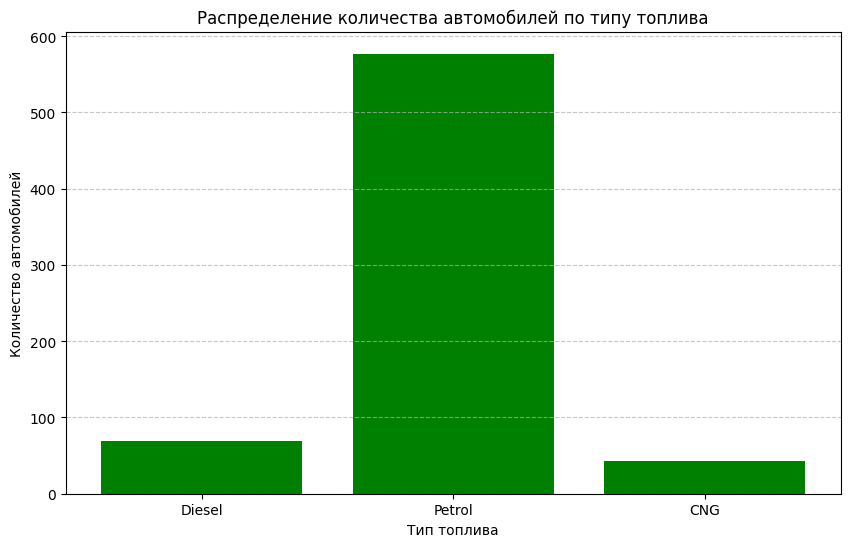

In [8]:
fuel = df['fuel_type'].unique() 
fuel_type = {brand: i for i, brand in enumerate(fuel)}  # преобразование в числовые категории
df['fuel_type_nums'] = df['fuel_type'].map(fuel_type)

count_by_fuel = df['fuel_type_nums'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(fuel, count_by_fuel.values, color='green')

ax.set_xlabel('Тип топлива')
ax.set_ylabel('Количество автомобилей')
ax.set_title('Распределение количества автомобилей по типу топлива')
ax.grid(axis='y', linestyle='--', alpha=0.7)


Диаграмма разброса значений стоимости автомобиля в зависимости от его пробега и типа трансмиссии

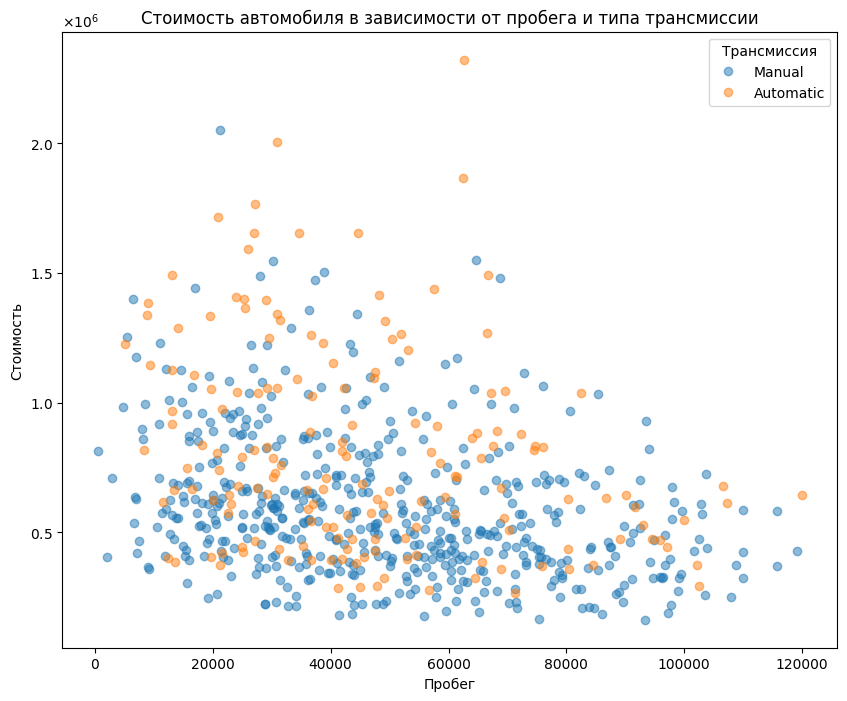

In [9]:
transmissions = df['transmission'].unique()

fig, ax = plt.subplots(figsize=(10, 8))

for transmission in transmissions:
    subset = df[df['transmission'] == transmission]
    ax.plot(subset['km_driven'], subset['price'], 'o', alpha=0.5, label=transmission)

ax.set_xlabel('Пробег')
ax.set_ylabel('Стоимость')
ax.set_title('Стоимость автомобиля в зависимости от пробега и типа трансмиссии')
ax.legend(title='Трансмиссия');

formatter = ScalarFormatter(useMathText=True) # отрисовывает экспоненту в виде 10**n
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

Круговая диаграмма распределения продаж по брендам

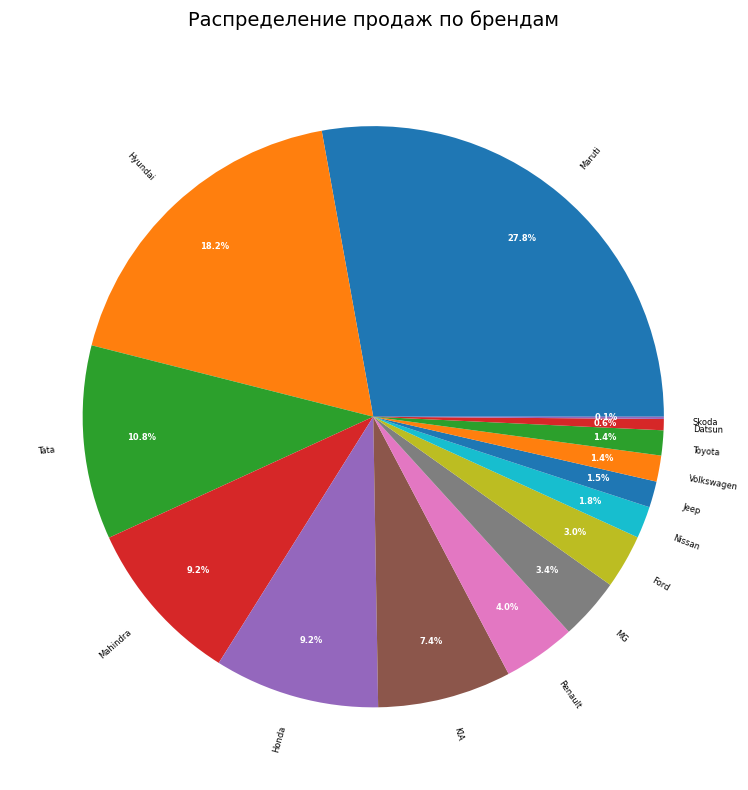

In [10]:
sales_by_brand = df.groupby('brand')['price'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

# Функция для автоподписи
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%"

wedges, texts, autotexts = ax.pie(sales_by_brand.values,
                                  labels=sales_by_brand.index,
                                  autopct=lambda pct: func(pct, sales_by_brand.values),
                                  textprops=dict(fontsize=9),
                                  labeldistance=1.1,  # расстояние для названий
                                  pctdistance=0.8,    # расстояние для процентов
                                  rotatelabels=True)  # поворот подписей для лучшей читаемости


plt.setp(autotexts, size=6, weight="bold", color="white")
plt.setp(texts, size=6)

ax.set_title('Распределение продаж по брендам', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Построить несколько суб-графиков на одном графике используя `.subplot`.  

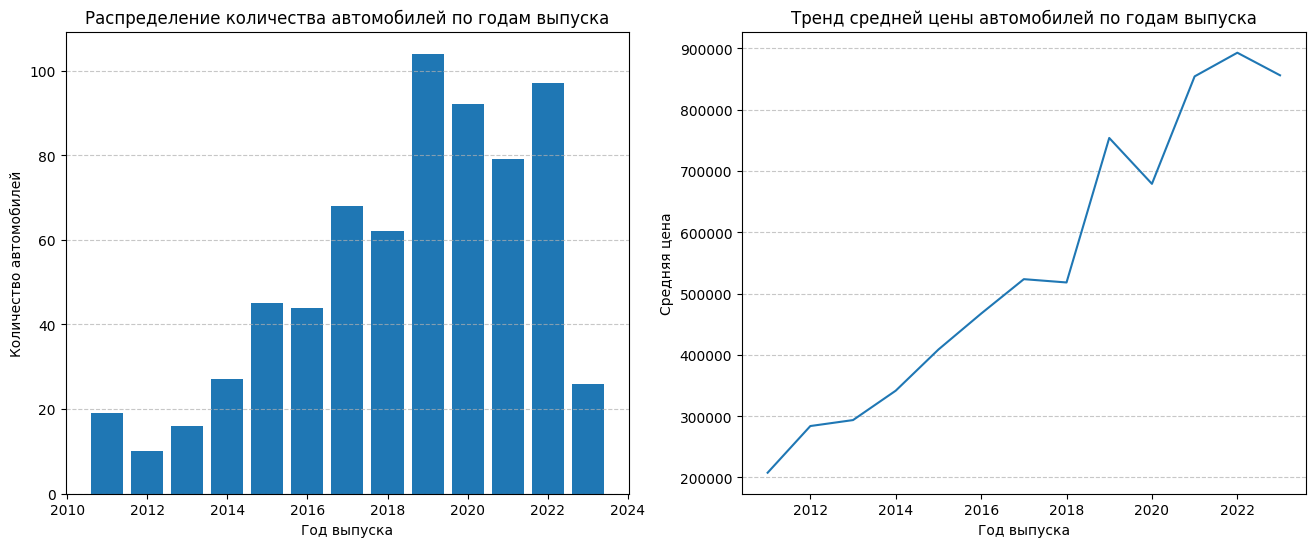

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

count_by_year = df['make_year'].value_counts().sort_index() #подсчет количества автомобилей по годам выпуска

ax[0].bar(count_by_year.index.astype(int), count_by_year.values)
ax[0].set_xlabel('Год выпуска')
ax[0].set_ylabel('Количество автомобилей')
ax[0].set_title('Распределение количества автомобилей по годам выпуска')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

mean_price_by_year = df.groupby('make_year')['price'].mean().sort_index() #сортируем по среднему значению цены сгруппированных данных по годам

ax[1].plot(mean_price_by_year.index, mean_price_by_year.values)
ax[1].set_xlabel('Год выпуска')
ax[1].set_ylabel('Средняя цена')
ax[1].set_title('Тренд средней цены автомобилей по годам выпуска')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

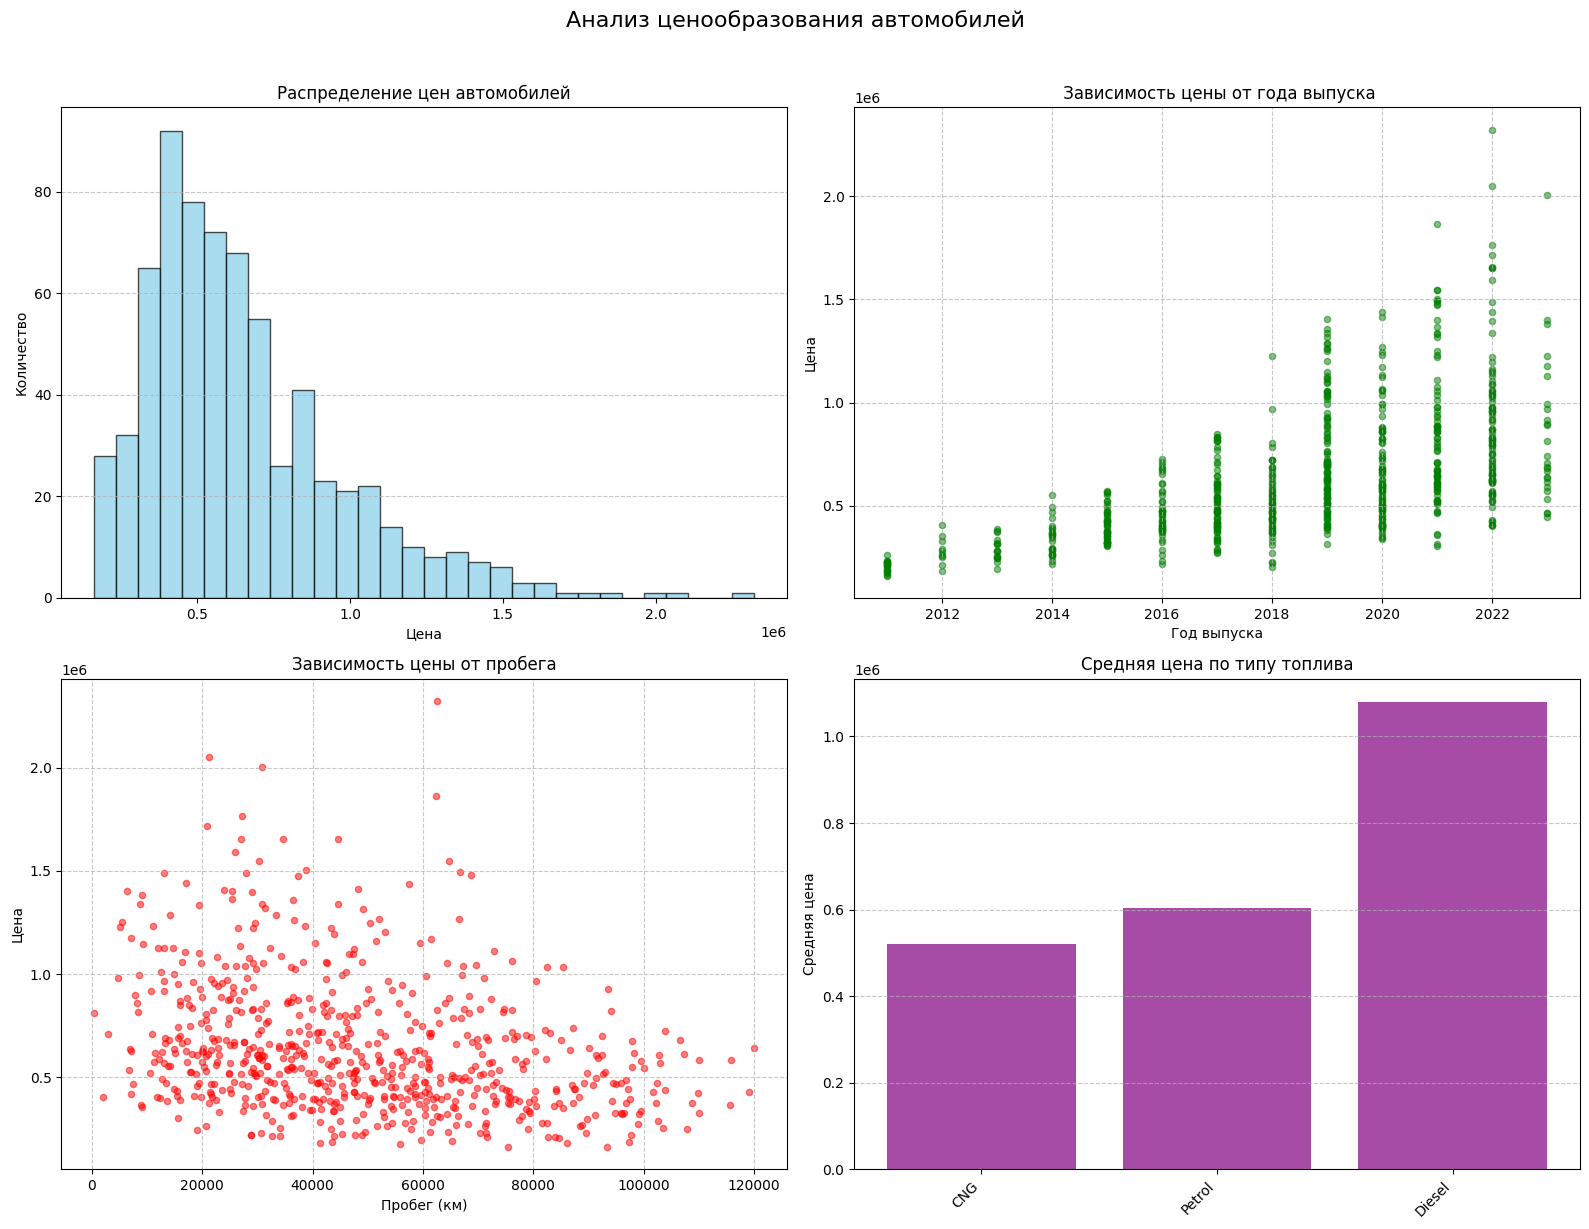

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 2, 1)
ax1.hist(df['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Распределение цен автомобилей', fontsize=12)
ax1.set_xlabel('Цена')
ax1.set_ylabel('Количество')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2 = plt.subplot(2, 2, 2)
ax2.scatter(df['make_year'], df['price'], alpha=0.5, c='green', s=20)
ax2.set_title(' Зависимость цены от года выпуска', fontsize=12)
ax2.set_xlabel('Год выпуска')
ax2.set_ylabel('Цена')
ax2.grid(True, linestyle='--', alpha=0.7)

ax3 = plt.subplot(2, 2, 3)
ax3.scatter(df['km_driven'], df['price'], alpha=0.5, c='red', s=20)
ax3.set_title('Зависимость цены от пробега', fontsize=12)
ax3.set_xlabel('Пробег (км)')
ax3.set_ylabel('Цена')
ax3.grid(True, linestyle='--', alpha=0.7)

ax4 = plt.subplot(2, 2, 4)
fuel_avg_price = df.groupby('fuel_type')['price'].mean().sort_values()
ax4.bar(range(len(fuel_avg_price)), fuel_avg_price.values, color='purple', alpha=0.7)
ax4.set_xticks(range(len(fuel_avg_price)))
ax4.set_xticklabels(fuel_avg_price.index, rotation=45, ha='right')
ax4.set_title('Средняя цена по типу топлива', fontsize=12)
ax4.set_ylabel('Средняя цена')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Анализ ценообразования автомобилей', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

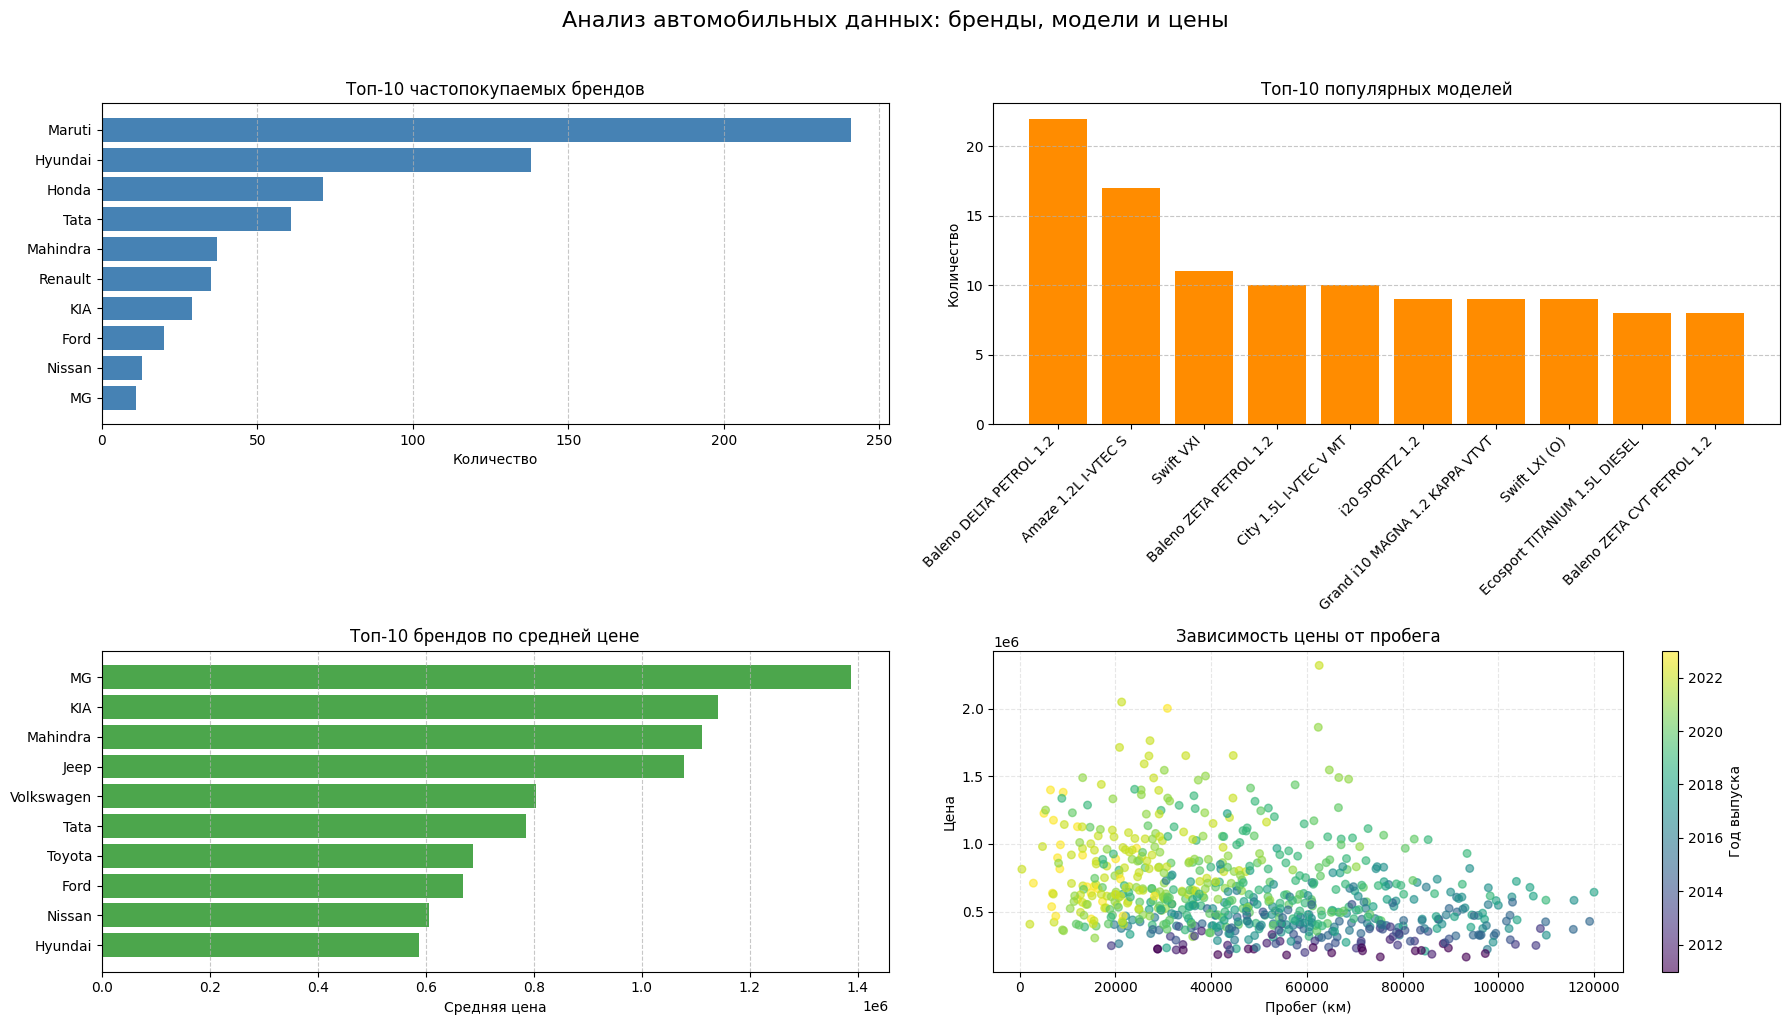

In [13]:
fig = plt.figure(figsize=(18, 10))

ax1 = plt.subplot(2, 2, 1)
top_brands = df['brand'].value_counts().head(10)
bars1 = ax1.barh(range(len(top_brands)), top_brands.values, color='steelblue')
ax1.set_yticks(range(len(top_brands)))
ax1.set_yticklabels(top_brands.index)
ax1.set_title('Топ-10 частопокупаемых брендов', fontsize=12)
ax1.set_xlabel('Количество')
ax1.invert_yaxis()  # Чтобы самый популярный был сверху
ax1.grid(axis='x', linestyle='--', alpha=0.7)

ax2 = plt.subplot(2, 2, 2)
top_models = df['model'].value_counts().head(10)
bars2 = ax2.bar(range(len(top_models)), top_models.values, color='darkorange')
ax2.set_xticks(range(len(top_models)))
ax2.set_xticklabels(top_models.index, rotation=45, ha='right')
ax2.set_title('Топ-10 популярных моделей', fontsize=12)
ax2.set_ylabel('Количество')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

ax3 = plt.subplot(2, 2, 3)
brand_avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
ax3.barh(range(len(brand_avg_price)), brand_avg_price.values, color='green', alpha=0.7)
ax3.set_yticks(range(len(brand_avg_price)))
ax3.set_yticklabels(brand_avg_price.index)
ax3.set_title('Топ-10 брендов по средней цене', fontsize=12)
ax3.set_xlabel('Средняя цена')
ax3.invert_yaxis()
ax3.grid(axis='x', linestyle='--', alpha=0.7)

ax5 = plt.subplot(2, 2, 4)
scatter = ax5.scatter(df['km_driven'], df['price'], 
                      c=df['make_year'], cmap='viridis', alpha=0.6, s=30)
ax5.set_title('Зависимость цены от пробега', fontsize=12)
ax5.set_xlabel('Пробег (км)')
ax5.set_ylabel('Цена')
plt.colorbar(scatter, ax=ax5, label='Год выпуска')
ax5.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Анализ автомобильных данных: бренды, модели и цены', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Построить интерактивный график со слайдером.

#### Интерактивный график, демонстрирующий тренд изменения средней цены на автомобили разных брендов во временном разрезе.

Слайдером можно регулировать начало временного интервала.

Легенда также является динамическим объектом, благодаря которому можно исключать информацию о бренде.

C:\Users\Mi\AppData\Local\Temp\ipykernel_22140\3906197781.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(brands))


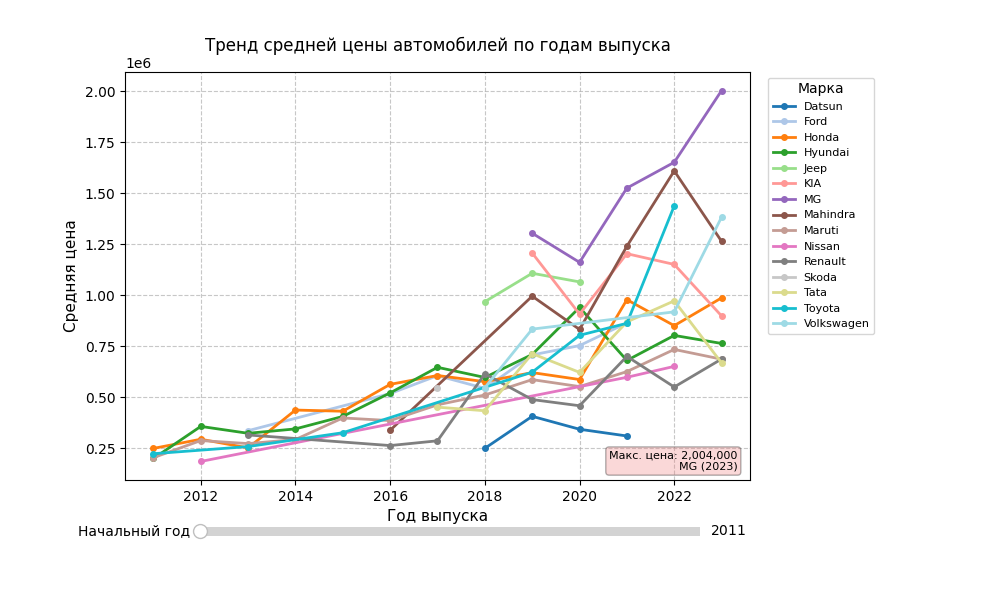

In [14]:
%matplotlib widget
from matplotlib.widgets import Slider, Button
import matplotlib.pyplot as plt

# Глобальные переменные для хранения ссылок на графики
fig_ipl = None
fig_pd = None
fig_sns = None
fig_sp = None

def close_mpl_fig(figure=None, exclude_list: list = []):
    """Закрывает фигуру Matplotlib с возможностью исключения"""
    fig = figure
    if fig is None:
        fig = plt.gcf()
    if fig not in exclude_list:
        plt.close(fig)

def mpl_iplot():
    """Создаёт интерактивный график для анализа цен автомобилей"""
    global fig_ipl, fig_pd, fig_sns, fig_sp
    
    close_mpl_fig(fig_ipl, [fig_pd, fig_sns, fig_sp])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Подготовка данных
    mean_price = df.groupby(['brand', 'make_year'])['price'].mean().reset_index()
    brands = mean_price['brand'].unique()
    cmap = plt.cm.get_cmap('tab20', len(brands))
    colors = [cmap(i) for i in range(len(brands))]
    
    # Словарь для хранения линий и их цветов
    lines_dict = {}
    lines_list = []
    
    # Построение линий для каждой марки
    for i, brand in enumerate(brands):
        brand_data = mean_price[mean_price['brand'] == brand].sort_values('make_year')
        line, = ax.plot(brand_data['make_year'], brand_data['price'], 
                        marker='o', label=brand, color=colors[i], 
                        linewidth=2, markersize=4)
        lines_dict[brand] = line
        lines_list.append(line)
    
    ax.set_xlabel('Год выпуска', fontsize=11)
    ax.set_ylabel('Средняя цена', fontsize=11)
    ax.set_title('Тренд средней цены автомобилей по годам выпуска', fontsize=12, pad=15)
    ax.grid(linestyle='--', alpha=0.7)
    
    leg = ax.legend(title='Марка', bbox_to_anchor=(1.02, 1), loc='upper left', 
                    frameon=True, fontsize=8)
    leg.set_draggable(False) # зафиксировали легенду
    
    # Настройка отступов
    fig.subplots_adjust(bottom=0.2, right=0.75)
    
    # Настройка кликабельности легенды
    lined = {}
    for legline, origline in zip(leg.get_lines(), lines_list):
        legline.set_picker(7)
        lined[legline] = origline
    
    def on_pick(event):
        legline = event.artist
        origline = lined[legline]
        visible = not origline.get_visible()
        origline.set_visible(visible)
        legline.set_alpha(1.0 if visible else 0.2)
        fig.canvas.draw()
    
    fig.canvas.mpl_connect('pick_event', on_pick)
    
    # Создание слайдера
    ax_year = fig.add_axes([0.2, 0.1, 0.5, 0.03])
    year_slider = Slider(
        ax=ax_year,
        label='Начальный год',
        valmin=int(mean_price['make_year'].min()),
        valmax=int(mean_price['make_year'].max()),
        valinit=int(mean_price['make_year'].min()),
        valstep=1,
        color='blue'
    )
    
    # Функция обновления
    def update(val):
        start_year = year_slider.val
        
        # Обновляем данные для каждой линии
        for brand, line in lines_dict.items():
            brand_data = mean_price[mean_price['brand'] == brand].sort_values('make_year')
            brand_data_filtered = brand_data[brand_data['make_year'] >= start_year]
            
            if not brand_data_filtered.empty:
                line.set_data(brand_data_filtered['make_year'], brand_data_filtered['price'])
                line.set_visible(True)
            else:
                line.set_visible(False)
        
        # Обновляем пределы осей
        ax.relim()
        ax.autoscale_view()
        
        # Обновляем заголовок
        ax.set_title(f'Тренд средней цены (с {start_year} года)', fontsize=12, pad=15)
        
        # Обновляем информацию
        visible_brands = len(mean_price[mean_price['make_year'] >= start_year]['brand'].unique())

        for txt in ax.texts:
            if 'Отображается марок' in txt.get_text() or 'Всего марок' in txt.get_text():
                txt.remove()
    
        ax.text(0.02, 0.98, f'Отображается марок: {visible_brands}/{len(brands)}', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        fig.canvas.draw_idle()
    
    year_slider.on_changed(update)
    
    max_price_idx = mean_price['price'].idxmax()
    max_info = mean_price.loc[max_price_idx]
    ax.text(0.98, 0.02, f"Макс. цена: {max_info['price']:,.0f}\n{max_info['brand']} ({int(max_info['make_year'])})", 
            transform=ax.transAxes, fontsize=8, verticalalignment='bottom', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))
    
    plt.show()
    return fig

fig_ipl = mpl_iplot()

## 4. `pandas`

### Построить три разных вида графиков с использованием `pandas.DataFrame.plot` / `Series.plot`.  
   
> - Среди графиков должен присутствовать один `boxplot` (обязательно надо использовать параметр `by` для исследования взаимосвязи числовой переменной и какой-либо другой).  
> - Графики должны быть построены как через методы `DataFrame`, так и через методы `Series`. То есть оба варианта нужно продемонстрировать.  

In [15]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import iplot, init_notebook_mode
init_notebook_mode(connected=True)

In [33]:
%matplotlib inline

#### Boxplot через DataFrame

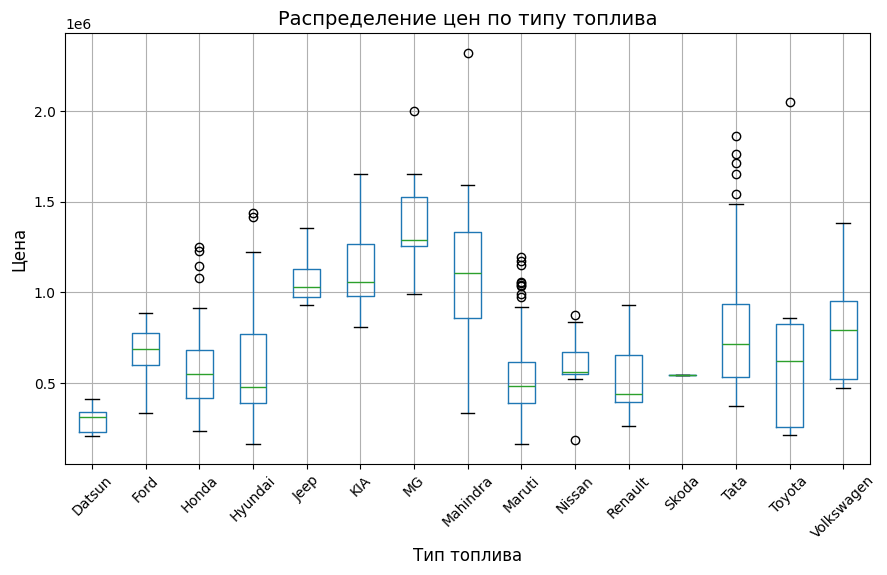

In [35]:
close_mpl_fig(fig_pd, [fig_ipl, fig_sns, fig_sp])

fig_pd, ax_pd = plt.subplots(figsize=(9, 6))

df.boxplot(column='price', by='brand', ax=ax_pd, grid=True)

ax_pd.set_title('Распределение цен по типу топлива', fontsize=14)
ax_pd.set_xlabel('Тип топлива', fontsize=12)
ax_pd.set_ylabel('Цена', fontsize=12)
plt.suptitle('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

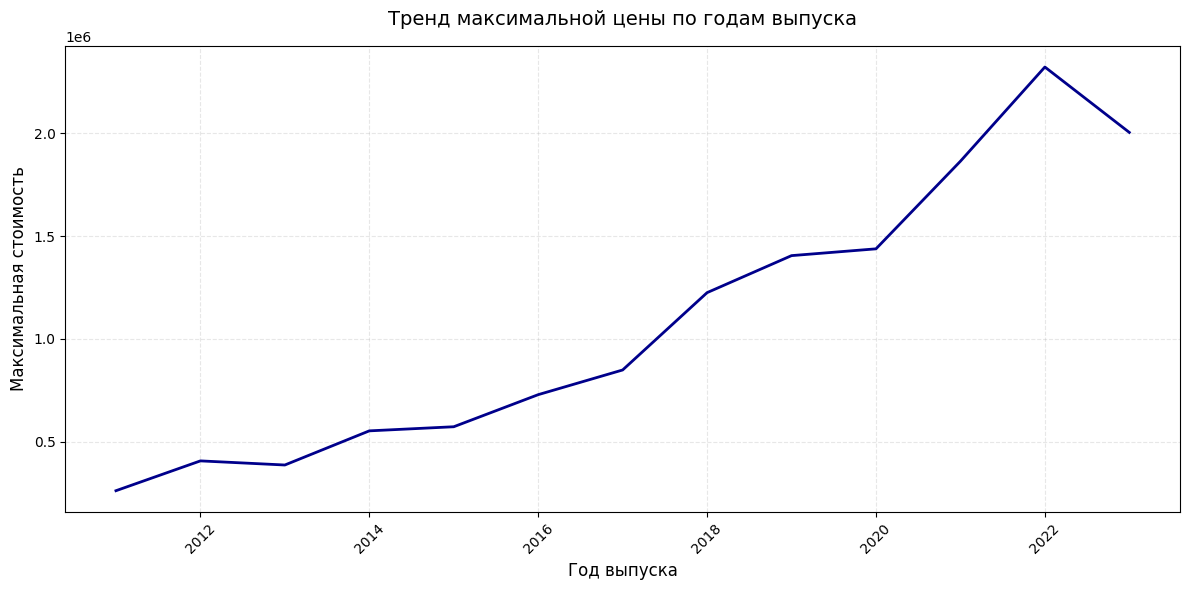

In [36]:
close_mpl_fig(fig_pd, [fig_ipl, fig_sns, fig_sp])

import matplotlib.pyplot as plt

max_price_by_year = df.groupby('make_year')['price'].max().sort_index() #сортируем по максимальному значению цены сгруппированных данных по годам

fig_pd, ax_pd = plt.subplots(figsize=(12, 6))

max_price_by_year.plot(
    kind='line',
    ax=ax_pd,
    linewidth=2,
    color='darkblue'
)

ax_pd.set_xlabel('Год выпуска', fontsize=12)
ax_pd.set_ylabel('Максимальная стоимость', fontsize=12)
ax_pd.set_title('Тренд максимальной цены по годам выпуска', fontsize=14, pad=15)
ax_pd.grid(True, alpha=0.3, linestyle='--')
ax_pd.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

#### График с помощью Series.plot

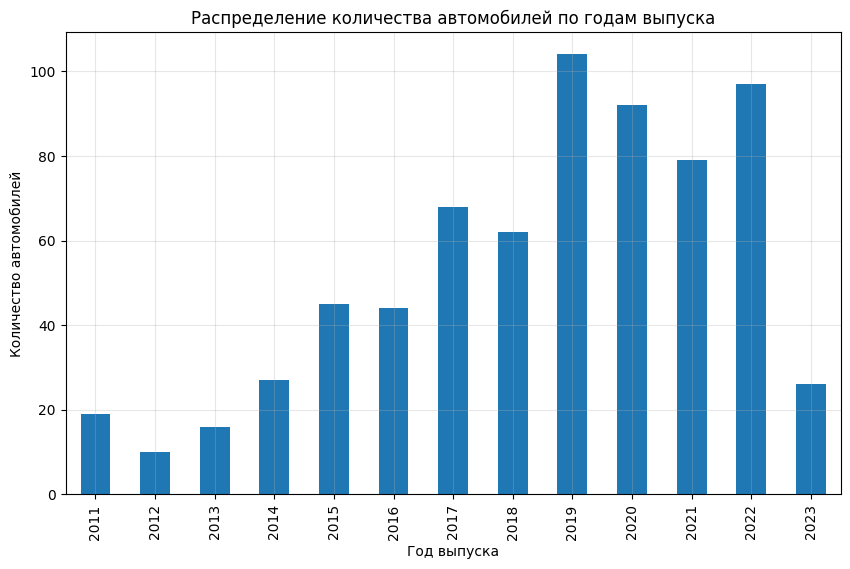

In [37]:
close_mpl_fig(fig_pd, [fig_ipl, fig_sns, fig_sp])

fig_pd, ax_pd = plt.subplots(figsize=(12, 6))

count_by_year = df['make_year'].value_counts().sort_index() #подсчет количества автомобилей по годам выпуска

count_by_year.plot(kind='bar', figsize=(10, 6))
ax_pd.bar(count_by_year.index.astype(int), count_by_year.values)

labels = [int(float(label.get_text())) for label in ax_pd.get_xticklabels()]
ax_pd.set_xticklabels(labels)

ax_pd.set_xlabel('Год выпуска')
ax_pd.set_ylabel('Количество автомобилей')
ax_pd.set_title('Распределение количества автомобилей по годам выпуска')
ax_pd.grid(True, alpha=0.3)

plt.show()

## 5. `seaborn`

### Построить `.pairplot` на каком-либо наборе данных, проанализировать взаимосвязь набора числовых признаков.    

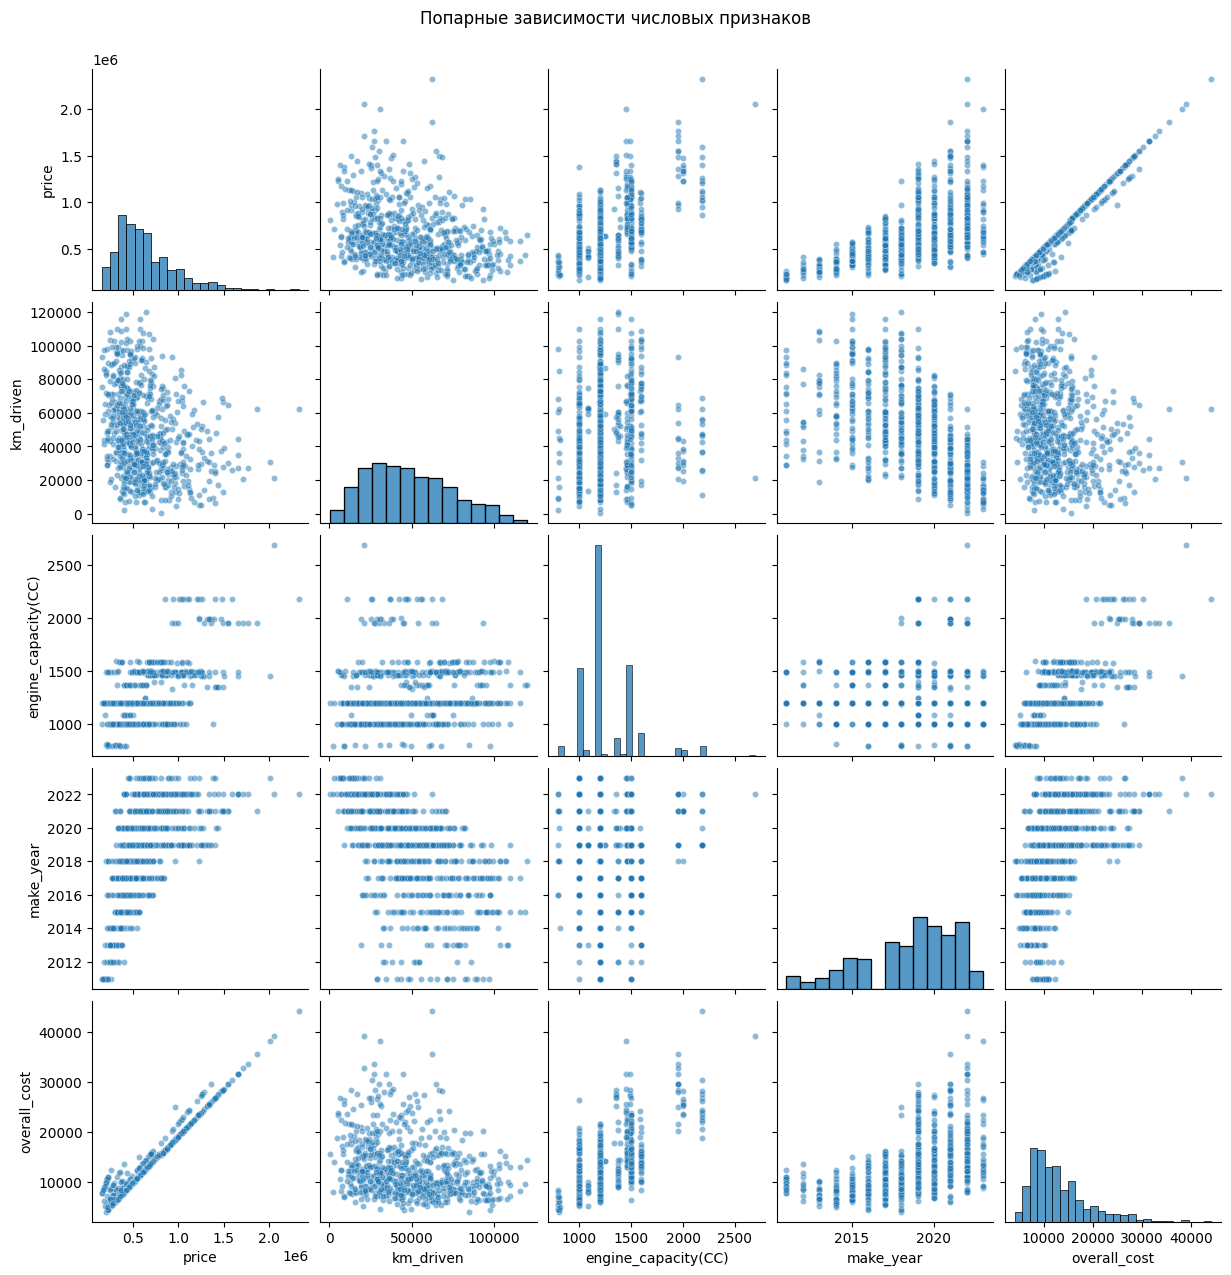

In [38]:
import seaborn as sns
close_mpl_fig(fig_sns, [fig_ipl, fig_pd, fig_sp])

numeric_cols = ['price', 'km_driven', 'engine_capacity(CC)', 'make_year', 'overall_cost']
df_numeric = df[numeric_cols].dropna()

g = sns.pairplot(data=df_numeric, diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
fig_sns = g.figure
fig_sns.suptitle('Попарные зависимости числовых признаков', y=1.02)
plt.show()


Анализ:
 - Стоимость автомобиля коррелирует с издержками на автомобиль (большинство значений лежат на прямой y = x, некоторые лежат выше);
 - На стоимость автомобиля влияет объем двигателя, поэтому городские автомобили (с объемом двигателя до 1500 sm**3) лежат в диапозоне стоимости от минимальной до средней;
 - Зависимость между пробегом автомобиля и его стоимостью - обратнопропорциональная (большой пробег = ниже цена);
 - Прямой зависимости между стоимостью автомобиля и годом его выпуска не обнаружено, на стоимость больше влияет бренд, чем год выпуска.

### Построить `.jointplot`, проанализировать взаимосвязь двух конкретных числовых признаков.  

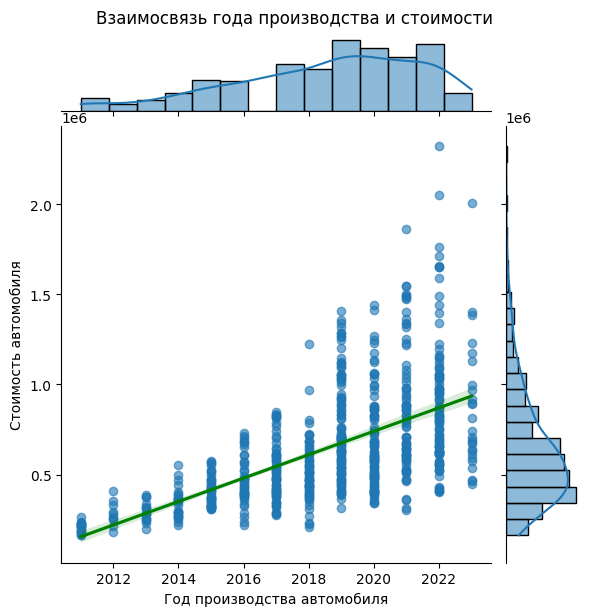

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

close_mpl_fig(fig_sns, [fig_ipl, fig_pd, fig_sp])

numeric_cols = ['price', 'km_driven', 'engine_capacity(CC)', 'make_year', 'overall_cost']
df_numeric = df[numeric_cols]

rename_dict = {
    'make_year': 'Год производства автомобиля',
    'price': 'Стоимость автомобиля'
}

df_numeric_renamed = df_numeric.rename(columns=rename_dict)

g = sns.jointplot(data=df_numeric_renamed, 
                x='Год производства автомобиля', 
                y='Стоимость автомобиля',         
                kind='reg', scatter_kws={'alpha': 0.6},
                line_kws={'color': 'green'})
fig_sns = g.figure
fig_sns.suptitle('Взаимосвязь года производства и стоимости', y=1.02)
plt.show()

### Построить `.boxplot` и/или `.violinplot` на каком-либо наборе данных, проанализировать числовой признак в разрезе категориального.  

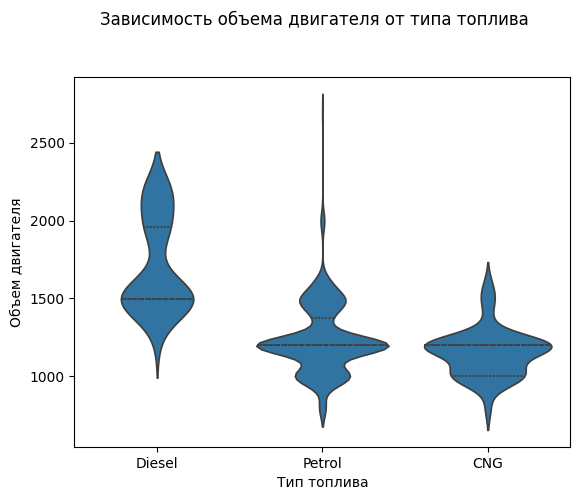

In [40]:
close_mpl_fig(fig_sns, [fig_ipl, fig_pd, fig_sp])

cols = ['fuel_type', 'engine_capacity(CC)']
df_cols = df[cols]

rename_dict = {
    'fuel_type': 'Тип топлива',
    'engine_capacity(CC)': 'Объем двигателя'
}

df_cols_renamed = df_cols.rename(columns=rename_dict)

g = sns.violinplot(data=df_cols_renamed, x='Тип топлива', y='Объем двигателя', inner='quartile')
fig_sns = g.figure
fig_sns.suptitle('Зависимость объема двигателя от типа топлива', y=1.02)
plt.show()

По violin plot мы можем проанализировать плотность точек на оси объема двигателя для каждого типа топлива.

По графику видим, что для жанров Petrol и CVG большая часть треков сосредоточена в диапозоне значений от 1000 до 1500 кубических сантиметров. Для Diesel есть два характерных значения, которые наиболее популярны для этого вида топлива - около 1500 сантиметров кубических и чуть более 2000 sm**3.

### Построить график `.heatmap` попарной корреляции всех числовых признаков.

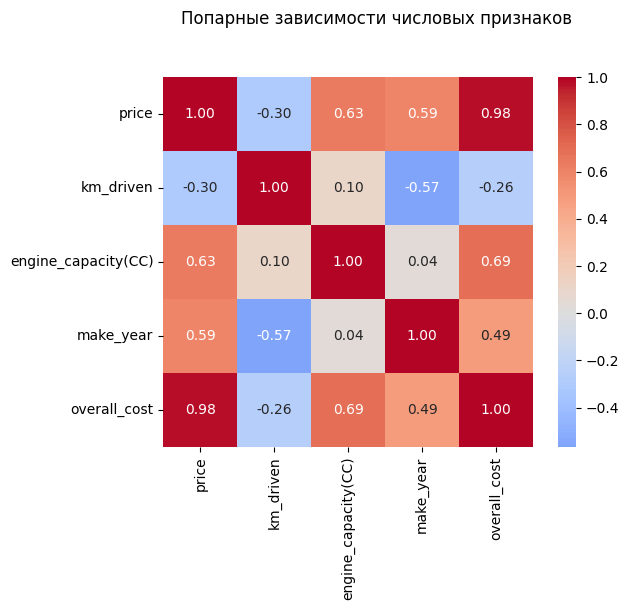

In [41]:
close_mpl_fig(fig_sns, [fig_ipl, fig_pd, fig_sp])

numeric_cols = ['price', 'km_driven', 'engine_capacity(CC)', 'make_year', 'overall_cost']
df_numeric = df[numeric_cols]

corr_matrix = df[numeric_cols].corr()

g = sns.heatmap(data=corr_matrix, 
                annot=True,          # Показать числа
                cmap='coolwarm',     # Красный=положительная, синий=отрицательная
                center=0,            # Центр в нуле
                square=True,         # Квадратные ячейки
                fmt='.2f')           # 2 знака после запятой
fig_sns = g.figure
fig_sns.suptitle('Попарные зависимости числовых признаков', y=1.02)
plt.show()


Исходя из результатов диаграммы корреляции, все выводы, сделанные на основании графика `.pairplot`, отражают корректность сформулированных гипотез.

## 6. `scipy.stats`

### Построить QQ-график (и гистограмму) для одного из числовых признаков с целью проверки на соответствие его распределения нормальному распределению. 

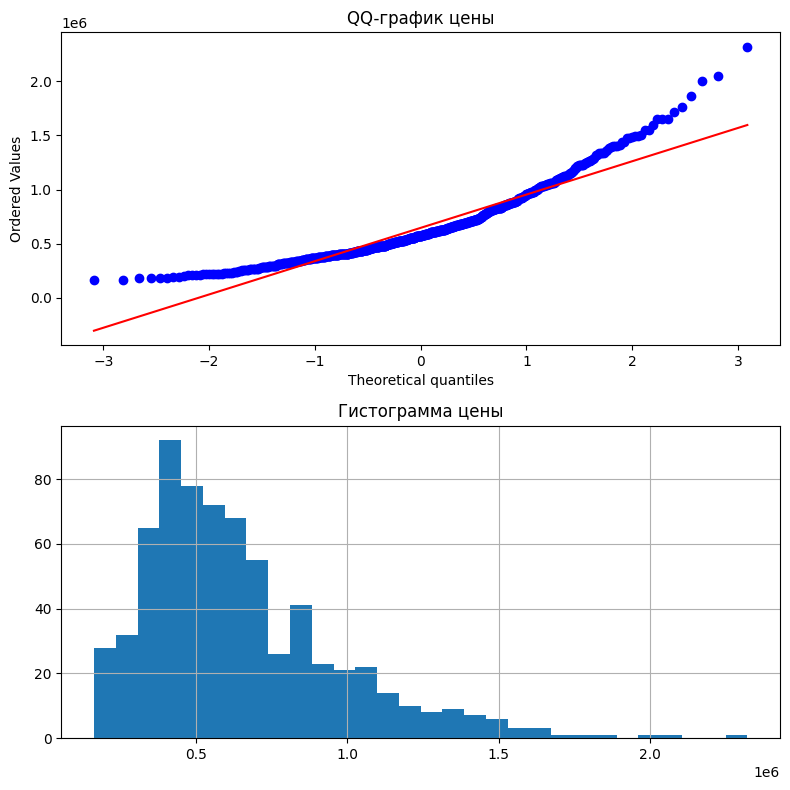

In [42]:
from scipy import stats
import matplotlib.pyplot as plt

close_mpl_fig(fig_sns, [fig_ipl, fig_pd, fig_sp])

fig, ax = plt.subplots(2, 1, figsize=(8, 8))

# QQ-график
stats.probplot(df['price'], dist="norm", plot=ax[0])
ax[0].set_title('QQ-график цены')

# Гистограмма
df.hist(ax=ax[1], column='price', bins=30)
ax[1].set_title('Гистограмма цены')

plt.tight_layout()
plt.show()

## 7. `plotly`

### Построить несколько графиков разного вида.  


In [43]:
import plotly.express as px

In [44]:
px.scatter(
    df, x='km_driven', y='price', opacity=0.1,
    title='Зависимость стоимости автомобиля от пробега'
).update_traces(
    marker=dict(color='red', size=6),
    hovertemplate='Пробег: %{x:,.0f} км<br>Стоимость: %{y:,.0f} ₽'
).update_layout(
    xaxis_title='Пробег (км)',
    xaxis_tickformat=',.0f',
    yaxis_title='Стоимость',
    yaxis_tickformat=',.0f',
    showlegend=False, width=800, height=500
).show()

In [45]:
fig = px.imshow(
    df[['price', 'km_driven', 'engine_capacity(CC)']].corr(), #вычисляем корреляционную матрицу
    title='Корреляционная матрица',
    color_continuous_scale='RdBu',
    zmin=-1,
    zmax=1,
    text_auto='.2f'  # Формат с двумя знаками после запятой
)

fig.show()

In [46]:
# базовая круговая диаграмму
fig = px.pie(
    df,
    values='price',
    names='brand',
    title='Распределение продаж по брендам',
    height=600
)

# выпадающее меню 
dropdown_buttons = [
    {
        'label': 'Любая коробка передач (All)',
        'method': 'update',
        'args': [
            {'values': [df['price']], 'labels': [df['brand']]},
            {'title': 'Распределение продаж по брендам'}
        ]
    },
    {
        'label': 'Автомат (Automatic)',
        'method': 'update',
        'args': [
            {'values': [df[df['transmission'] == 'Automatic']['price']], 
             'labels': [df[df['transmission'] == 'Automatic']['brand']]},
            {'title': 'Распределение продаж по брендам (Автомат)'}
        ]
    },
    {
        'label': 'Механика (Manual)',
        'method': 'update',
        'args': [
            {'values': [df[df['transmission'] == 'Manual']['price']], 
             'labels': [df[df['transmission'] == 'Manual']['brand']]},
            {'title': 'Распределение продаж по брендам (Механика)'}
        ]
    }
]

# добавляем выпадающее меню в график
fig.update_layout(
    title_x=0.5,  # Центрируем заголовок 
    legend=dict(
        x=-0.1,   # Легенда слева 
        y=0.5,
        xanchor='right',
        yanchor='middle'
    ),
    updatemenus=[
        {
            'buttons': dropdown_buttons,
            'direction': 'down',
            'showactive': True,
            'x': 1.1,
            'xanchor': 'left',
            'y': 1.1,
            'yanchor': 'top'
        }
    ]
)

fig.show()

In [47]:
import plotly.express as px

fig = px.histogram(
    df,
    x='brand',
    color='fuel_type',
    title='Доля типов топлива по брендам (в %)',
    labels={'brand': 'Бренд', 'count': 'Доля, %'},
    barnorm='percent', 
    category_orders={'brand': df['brand'].value_counts().index},
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    xaxis_title='Бренд',
    yaxis_title='Доля, %',
    xaxis={'tickangle': 45},
    width=800,
    height=500,
    legend_title='Тип топлива'
)

fig.show()

### Построить несколько суб-графиков на одном графике.

In [48]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Тепловая карта: бренды vs топливо',
                    'Ящик с усами: цена по топливу'),
    specs=[
        [{'type': 'heatmap'}, {'type': 'xy'}]
    ]
)

heatmap_data = pd.crosstab(df['brand'], df['fuel_type'])

fig.add_trace(
    go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index,
        colorscale='YlGnBu',
        text=heatmap_data.values,
        texttemplate='%{text}',
        textfont={"size": 10},
        colorbar=dict(title="Частота")
    ),
    row=1, col=1
)

for fuel in df['fuel_type'].unique():
    fuel_data = df[df['fuel_type'] == fuel]['price']
    fig.add_trace(
        go.Box(
            y=fuel_data,
            name=fuel,
            boxmean='sd'
        ),
        row=1, col=2
    )

# Обновляем макет
fig.update_layout(
    height=600,
    width=800,
    title_text="Анализ автомобильных данных",
    showlegend=False
)

# Обновляем подписи осей
fig.update_xaxes(title_text="Бренд", row=1, col=1)
fig.update_yaxes(title_text="Тип топлива", row=1, col=1)

fig.update_xaxes(title_text="Тип топлива", row=1, col=2)
fig.update_yaxes(title_text="Цена", row=1, col=2)

fig.show()

### Построить интерактивный график.

In [49]:
import plotly.express as px

mean_price_by_year = df.groupby('make_year')['price'].mean().reset_index()

fig = px.line(
    mean_price_by_year,
    x='make_year',
    y='price',
    title='Тренд средней цены автомобилей по годам выпуска',
    labels={'make_year': 'Год выпуска', 'price': 'Средняя цена'},
    markers=True
).add_trace(
    px.scatter(mean_price_by_year, x='make_year', y='price').data[0]
)


fig.update_layout(
    xaxis_title='Год выпуска',
    yaxis_title='Средняя цена',
    xaxis=dict(
        showgrid=False,
        tickformat='d'  # Целые числа для лет
    ),
    yaxis=dict(
        gridcolor='lightgray',
        griddash='dash'
    ),
    plot_bgcolor='white',
    width=900,
    height=600
)


fig.update_layout(
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}],
                'label': 'Воспроизвести',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Остановить',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 10},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }]
)

# добавляем кадры для анимации
frames = []
for year in mean_price_by_year['make_year'].sort_values().unique():
    frame_data = mean_price_by_year[mean_price_by_year['make_year'] <= year]
    frames.append(go.Frame(data=[
        go.Scatter(
            x=frame_data['make_year'],
            y=frame_data['price'],
            mode='lines+markers'
        )
    ]))

fig.frames = frames

fig.show()

### Построить интерактивный график (с использованием Dash)

In [50]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

app = Dash(__name__)

app.layout = html.Div([
    html.H1("Анализ автомобильных данных",
            style={'textAlign': 'center', 'color': '#2c3e50'}),

    html.Div([
        html.Div([
            html.Label("Выберите тип графика:"),
            dcc.RadioItems(
                id='plot-type',
                options=[
                    {'label': ' Распределение продаж по брендам', 'value': 'donut'},
                    {'label': ' Распределение цен', 'value': 'hist'},
                    {'label': ' Цена по типу топлива', 'value': 'box'},
                    {'label': ' Топ-10 брендов', 'value': 'bar'}
                ],
                value='donut',
                labelStyle={'display': 'block', 'margin': '10px'}
            )
        ], style={'width': '20%', 'display': 'inline-block', 'verticalAlign': 'top',
                  'padding': '20px', 'backgroundColor': '#f8f9fa', 'borderRadius': '10px'}),

        html.Div([
            dcc.Graph(id='main-plot')
        ], style={'width': '75%', 'display': 'inline-block'})
    ]),

    html.Div(id='stats', style={'padding': '20px', 'textAlign': 'center'})
])


@app.callback(
    [Output('main-plot', 'figure'),
     Output('stats', 'children')],
    [Input('plot-type', 'value')]
)
def update_plot(plot_type):
    stats = ""  # Инициализируем stats по умолчанию

    if plot_type == 'donut':
        brand_counts = df['brand'].value_counts().reset_index()
        brand_counts.columns = ['brand', 'count']

        fig = px.pie(
            brand_counts,
            values='count',
            names='brand',
            title='Распределение продаж по брендам',
            hole=0.4,
            height=600
        )

        stats = f"Всего брендов: {len(brand_counts)} | Всего автомобилей: {len(df)}"

        dropdown_buttons = [
            {
                'label': 'Все автомобили',
                'method': 'update',
                'args': [
                    {'values': [brand_counts['count']],
                     'labels': [brand_counts['brand']]},
                    {'title': 'Распределение продаж по брендам'}
                ]
            },
            {
                'label': 'Автомат (Automatic)',
                'method': 'update',
                'args': [
                    {'values': [df[df['transmission'] == 'Automatic']['brand'].value_counts().values],
                     'labels': [df[df['transmission'] == 'Automatic']['brand'].value_counts().index]},
                    {'title': 'Распределение продаж по брендам (Автомат)'}
                ]
            },
            {
                'label': 'Механика (Manual)',
                'method': 'update',
                'args': [
                    {'values': [df[df['transmission'] == 'Manual']['brand'].value_counts().values],
                     'labels': [df[df['transmission'] == 'Manual']['brand'].value_counts().index]},
                    {'title': 'Распределение продаж по брендам (Механика)'}
                ]
            }
        ]

        fig.update_layout(
            title_x=0.5,
            legend=dict(
                x=-0.1,
                y=0.5,
                xanchor='right',
                yanchor='middle'
            ),
            updatemenus=[
                {
                    'buttons': dropdown_buttons,
                    'direction': 'down',
                    'showactive': True,
                    'x': 1.1,
                    'xanchor': 'left',
                    'y': 1.1,
                    'yanchor': 'top'
                }
            ]
        )

    elif plot_type == 'hist':
        fig = px.histogram(df, x='price', nbins=30,
                           title='Распределение цен',
                           marginal='box')
        stats = f"Средняя цена: {df['price'].mean():,.0f} | Медиана: {df['price'].median():,.0f}"

    elif plot_type == 'box':
        fig = px.box(df, x='fuel_type', y='price',
                     title='Распределение цен по типу топлива',
                     color='fuel_type')
        stats = f"Макс цена: {df['price'].max():,.0f} | Мин цена: {df['price'].min():,.0f}"

    else:  # bar
        top_brands = df['brand'].value_counts().head(10).sort_values(ascending=True) # здесь сортируем по убыванию, чтобы сверху был максимум
        fig = px.bar(x=top_brands.values, y=top_brands.index,
                     orientation='h', title='Топ-10 брендов частопокупаемых брендов',
                     labels={'x': 'Количество', 'y': ''})
        stats = f"Всего брендов: {df['brand'].nunique()} | Всего автомобилей: {len(df)}"

    return fig, stats


if __name__ == '__main__':
    app.run(debug=True, port=8080)